### ライブラリの準備

###モジュールのインポートとGoogleドライブのマウント

In [1]:
import os
import glob
import math
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import datetime
#from tqdm import tqdm
from tqdm.notebook import tqdm
import pickle
import random
from torch.utils.data import Dataset, DataLoader
from torch.utils.data.sampler import SubsetRandomSampler
from PIL import Image
import skimage.transform
from collections import deque
from typing import Sequence, Dict, Tuple, Union

import torch
from torch import nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pack_padded_sequence
from torchvision import models
import torchvision.transforms as T
import torchvision.datasets as dataset
from torchvision.transforms import v2

from timm.scheduler import CosineLRScheduler
from transformers import  get_linear_schedule_with_warmup

#from transformers import AutoImageProcessor, AutoModel, AutoProcessor, CLIPVisionModel
from transformers import BertTokenizer, BertModel, CLIPVisionModel, BertForPreTraining

import sys

import util
import levenshtein
from nltk import bleu_score
import ssl
from torch.amp import autocast, GradScaler

In [2]:
class PositionalEmbedding(nn.Module):
    '''
    位置埋め込み （Positional embedding）
    dim_embedding: 埋込み次元
    max_len      : 入力の最大系列長
    '''
    def __init__(self, dim_embedding: int, max_len: int=2048):
        super().__init__()

        self.pos_emb = nn.Embedding(max_len, dim_embedding)

    '''
    位置エンコーディングの順伝播
    x: 位置エンコーディングを埋め込む対象のテンソル,
       [バッチサイズ, 系列長, 埋め込み次元]
    '''
    def forward(self, x: torch.Tensor):
        seq = x.shape[1]
        positions = torch.arange(start=0, end=seq, step=1, device=x.device).to(torch.long)
        positions = self.pos_emb(positions)[:seq,:]
        
        return positions

### CaptioningTransformer

In [32]:
class CaptioningTransformer(nn.Module):
    '''
    CaptioningTransformerのコンストラクタ
    dim_embedding  : 埋め込み次元
    dim_feedforward: FNNの中間特徴次元
    num_heads      : マルチヘッドアテンションのヘッド数
    num_layers     : Transformerデコーダ層の数
    vocab_size     : 辞書の次元
    null_index     : NULLのID
    dropout        : ドロップアウト確率
    '''
    def __init__(self, img_size: int, length_max: int, dim_embedding: int,
                  vocab_size: int, tokenizer, dropout: float=0.1, model_id: str=''):
        super().__init__()

        self.mask_token_id = tokenizer.mask_token_id
        self.pad_token_id = tokenizer.pad_token_id
        self.max_idx_en = len( tokenizer )

        #CLIP
        clip_model_id = "openai/clip-vit-large-patch14-336"
        self.clip_model = CLIPVisionModel.from_pretrained(clip_model_id, output_hidden_states = True)
        images = torch.randn( ( 1, 3, img_size, img_size ) )
        memory = self.clip_model( images )
        memory = memory.last_hidden_state
        img_length = memory.size(1)
        clip_dim = memory.size(2)
        self.ln_memory = nn.LayerNorm( dim_embedding )

        self.emb = nn.Embedding( vocab_size, dim_embedding )
        self.pos_emb = PositionalEmbedding( dim_embedding )

        self.dropout = nn.Dropout( dropout )

        self.dc_linear = nn.Linear( clip_dim * 3, dim_embedding )

        # Down Sampling
        #img_length = 577
        #length_max = 84
        stride = img_length // length_max
        #stride = 6
        self.conv1 = nn.Conv1d( dim_embedding, dim_embedding, 1, stride )
        print( "img_length:", img_length )
        print( "text_length_max:", length_max )
        print( "stride:", stride )
        
        self.bert = BertModel.from_pretrained( model_id )

        ## 単語出力分布計算
        self.ln_outputs = nn.LayerNorm( dim_embedding )
        self.linear = nn.Linear(dim_embedding, vocab_size)

        self.dim_embedding = dim_embedding
        self.length_max = length_max

    ''' CaptioningTransformerの順伝播処理
    features: 画像特徴量 [バッチサイズ, 埋め込み次元]
    captions: 正解キャプション [バッチサイズ, 系列長]
    '''
    def forward(self, images: torch.Tensor, captions: torch.Tensor ):

        self.device = images.device

        caption_lengths = torch.ones( ( captions.size(0) ), dtype=torch.long, device = self.device ) * self.length_max
        masked_captions, mask = self.masking( captions, caption_lengths )
        
        memory = self.clip_model( images )
        memory = self.dense_connector( memory )
        memory = self.dropout( memory )
        memory = self.ln_memory( memory )

        memory = self.conv1( memory.transpose(1,2) ).transpose(1,2)
        
        emb_caption = self.emb( masked_captions ) * math.sqrt(self.dim_embedding)
        emb_caption += self.pos_emb( emb_caption )

        bert_in = torch.cat( [memory, emb_caption], dim = 1 )
        #bert_in_padding_masks = None
        bert_in_padding_masks = torch.ones_like( masked_captions, device = self.device, dtype=torch.float )
        bert_in_padding_masks = torch.cat( [torch.ones( memory.shape[:2], device=model.device ), bert_in_padding_masks], dim = 1 )
        
        outputs = self.bert( inputs_embeds = bert_in, attention_mask = bert_in_padding_masks ).last_hidden_state
        outputs = outputs[:,memory.size(1):,:]
        outputs = self.ln_outputs( outputs )
        logits = self.linear( outputs )
        
        return logits, mask

    def dense_connector(self, memory ):
        tmp1 = torch.tensor([], device = self.device )
        tmp2 = torch.tensor([], device = self.device )
        tmp_full = len( memory.hidden_states )
        tmp_half = tmp_full // 2
        for i in range( 0, tmp_half ):
            tmp1 = torch.cat( [tmp1, memory.hidden_states[i][None]], dim = 0 )
        tmp1 = torch.sum(tmp1, dim=0) / tmp_half
        for i in range( tmp_half, tmp_full ):
            tmp2 = torch.cat( [tmp2, memory.hidden_states[i][None]], dim = 0 )
        tmp2 = torch.sum(tmp2, dim=0 ) / ( tmp_full - tmp_half )
        tmp3 = torch.cat([tmp1, tmp2], dim=-1)
        tmp3 = torch.cat( [ memory.last_hidden_state, tmp3], dim = -1 )
        tmp3 = self.dc_linear( tmp3 )
        return tmp3

    def masking(self, input_x: torch.Tensor, lengths: torch.Tensor) -> tuple[torch.Tensor]:

        output = input_x.clone()

        masks = torch.zeros_like( output, device=output.device, dtype=torch.bool )       
        
        #sum_num_mask = 0
        #sum_num_arbi = 0
        #sum_num_nochange = 0
        for n in range( output.size(0) ):
            #all_prob = torch.normal( torch.tensor( 0.7 ), torch.tensor( 0.2 ) )
            all_prob = torch.normal( torch.tensor( 0.8 ), torch.tensor( 0.2 ) )
            all_prob = torch.clamp( all_prob, min = 0.0, max = 1.0 )
            if all_prob > 0.99:
                num_mask = lengths[n]
                num_arbi = 0
                num_nochange = 0
            else:
                #mask_prob0 = torch.normal( torch.tensor( 0.7 ), torch.tensor( 0.2 ) )
                mask_prob0 = torch.normal( torch.tensor( 0.8 ), torch.tensor( 0.2 ) )
                mask_prob0 = torch.clamp( mask_prob0, min = 0.0, max = 1.0 )
                mask_prob = all_prob * mask_prob0
                resi_prob = all_prob * ( 1.0 - mask_prob0 )
                arbi_prob = all_prob * ( resi_prob * 0.5 )
                nochange_prob = all_prob * ( resi_prob * 0.5 )
                num_mask = math.floor( lengths[n].item() * mask_prob )
                num_arbi = math.floor( lengths[n].item() * arbi_prob )
                num_nochange = math.floor( lengths[n].item() * nochange_prob )

            #sum_num_mask += num_mask
            #sum_num_arbi += num_arbi
            #sum_num_nochange += num_nochange
            
            mask_mask = list( random.sample( list(range( 0, lengths[n])),  num_mask ))
            output[n,mask_mask] = self.mask_token_id
            not_mask_mask = [ n for n in range( lengths[n] ) if n not in mask_mask ]
            mask_arbi = random.sample( not_mask_mask, num_arbi )
            for i in range( lengths[n] ):
                if i in mask_arbi:
                    output[n,i] = torch.randint( 0, self.max_idx_en, size=(1,))
            not_mask_arbi = [ n for n in not_mask_mask if n not in mask_arbi ]
            mask_nochange = random.sample( not_mask_arbi, num_nochange )
            not_mask_nochange = [ n for n in not_mask_arbi if n not in mask_nochange ]
            mask = [ False if n in not_mask_nochange else True for n in range(lengths[n]) ]
            masks[n,:lengths[n]] = torch.tensor( mask )

        #print( "sum_num_mask:", sum_num_mask )
        #print( "calculate num mask:", torch.sum( torch.eq( output, self.mask_token_id ).int() ) )
        #print( "sum_num_mask + sum_num_arbi :", sum_num_mask + sum_num_arbi )
        #print( "num not equal:", torch.sum( torch.ne( input_x, output ).int() ) )
        #print( "sum_num_mask + sum_num_arbi + sum_nochange:", sum_num_mask + sum_num_arbi + sum_num_nochange )
        #print( "num of mask True:", torch.sum( torch.eq( masks, True ) ) )
        
        return output, masks

    def my_decode(self, token_list, tokenizer ):

        def my_index( l, x ):
            if x in l:
                return l.index(x)
            else:
                return -1
        if my_index( token_list, tokenizer.sep_token_id ) != -1:
            token_list = token_list[:my_index( token_list, tokenizer.sep_token_id )]
        else:
            token_list = token_list
            
        text = tokenizer.decode( token_list, skip_special_tokens = True )
        
        return text

In [33]:
class MyDataset(Dataset):
    def __init__(self, file_path: str, img_directory: str, transforms, tokenizer, length_max = None ) -> None:
        super().__init__()
        self.img_directory = img_directory
        self.transforms = transforms
        # TODO: fix to original data
        #画像の前処理
        self.img_file = []
        self.tokens = []
        if length_max == None:
            self.length_max = 0
        else:
            self.length_max = length_max
        length_sum = 0
        with open( file_path, "r" ) as f:
            #line = f.readline()
            #i = 0
            #while line:
            for i, line in enumerate( f ):
                if i % 100000 == 0:
                #    #print( line.split("\t")[0])
                #    #print( line.split("\t")[1])
                    print( "i:", i )
                #i += 1
                self.img_file.append(line.split("\t" )[0])
                caption = line.split("\t")[1].replace( "\r\n", "" ).replace( "\n", "").replace( "\r", "" )
                #print( "caption:", caption )
                id_tokens = tokenizer.encode( caption )
                length_sum += len( id_tokens )
                if length_max == None:
                    if self.length_max < len( id_tokens ):
                        self.length_max = len( id_tokens )
                    #id_tokens = torch.tensor( id_tokens, requires_grad = False  )
                    id_tokens = torch.tensor( id_tokens  )
                else:
                    #id_tokens = torch.tensor( id_tokens, requires_grad = False)[:length_max]
                    id_tokens = torch.tensor( id_tokens )[:length_max]
                
                #print( "id_tokens:", id_tokens )
                self.tokens.append( id_tokens )

                #line = f.readline()
        print("avg len:", length_sum / len( self.tokens ) )    
    
    # ここで取り出すデータを指定している
    def __getitem__(
        self,
        index: int
    ):
        tokens = self.tokens[index]
        img_file = self.img_file[index] + ".jpg"
        img_path = os.path.join( self.img_directory, img_file ) #index番目の画像のパスを取得
        img = Image.open(img_path) #PIL形式で画像を読み込み
        if img.mode != 'RGB':
            img = img.convert("RGB")
        img = self.transforms(img)
        
        return img, tokens

    # この method がないと DataLoader を呼び出す際にエラーを吐かれる
    def __len__(self) -> int:
        return len(self.tokens)

    def length_max(self):
        return self.length_max

In [34]:
def collate_func(batch: Sequence[Tuple[Union[torch.Tensor, str]]], pad_index, length_max ):
    imgs, tokens = zip(*batch)

    #max_length = 0
    #for target in tokens:
    #    if max_length < len( target ):
    #        max_length = len( target )
    max_length = length_max
    
    targets = []
    lengths = []
    for target in tokens:
        pad_len = max_length - len( target ) 
        input2= F.pad( target, (0, pad_len), mode='constant', value = pad_index)
        targets.append( input2 )
        lengths.append( len( target ) )
    
    imgs = torch.stack( imgs, dim = 0 )
    targets = torch.stack( targets, dim = 0 )
    lengths = torch.tensor( lengths  )
   
    return imgs, targets, lengths

In [6]:
# 画像のtransformsを定義
transforms = v2.Compose([
    v2.Resize((336, 336)),
    #v2.AutoAugment(),
    #v2.ToTensor(),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    ## Coco データセット 2017 train の平均と標準偏差
    #v2.Normalize((0.456,0.427,0.401),(0.224,0.219,0.231) )
    ## ImageNetデータセットの平均と標準偏差
    #v2.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225))
    # clip の preprocessor_config.json の平均と標準偏差
    v2.Normalize((0.48145466, 0.4578275, 0.40821073), (0.26862954, 0.26130258, 0.27577711))
])

model_id = "google-bert/bert-large-uncased"
tokenizer = BertTokenizer.from_pretrained(model_id)
length_max = 84

# v7 データセット
train_dataset = MyDataset( file_path="../CLIP_LLM_AR/dataset.txt",
                           img_directory = "/mnt/ssd2/v7/img",
                           #img_directory = "smb://192.168.1.2/img/v7/",
                           transforms=transforms, tokenizer = tokenizer, length_max = length_max )

# Subset samplerの生成
test_set, val_set, train_set = util.generate_subset_test_val_train(
    train_dataset, 0.1, 0.1 )
    
# 学習時にランダムにサンプルするためのサンプラー
train_sampler = SubsetRandomSampler(train_set)

# DataLoaderを生成
collate_func_lambda = lambda x: collate_func(x, tokenizer.pad_token_id, length_max )

test_loader = torch.utils.data.DataLoader(
                    train_dataset,
                    #batch_size=config.batch_size,
                    batch_size=1,
                    num_workers=0,
                    sampler=test_set,
                    collate_fn=collate_func_lambda)


/home/uchiyats/.local/lib/python3.12/site-packages/huggingface_hub/file_download.py:945: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


i: 0
i: 100000
i: 200000
i: 300000
i: 400000
i: 500000
avg len: 42.0877771734418


###学習におけるハイパーパラメータやオプションの設定

In [217]:
#device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")
## 辞書（単語→単語ID）の読み込み
#with open('../PreTrain_Decoder/translateDatasetNTT_blank4_pad0/word_to_id2.pkl', 'rb') as f:
#    word_to_id = pickle.load(f)
#max_idx_en = len( word_to_id )
#word_to_id['<mask>'] = max_idx_en
#mask_value = word_to_id['<mask>']
#start_idx = word_to_id['<start>']
#bert_model_path = 'models--google-bert--bert-large-uncased/snapshots/6da4b6a26a1877e173fca3225479512db81a5e5b'
#tokenizer = BertTokenizer.from_pretrained(pretrained_model_name_or_path = bert_model_path )
model_id = "google-bert/bert-large-uncased"
tokenizer = BertTokenizer.from_pretrained(model_id)
model = CaptioningTransformer(img_size = 336, length_max = 84, dim_embedding=1024, vocab_size=len(tokenizer),
                 tokenizer=tokenizer, dropout=0.1, model_id =model_id).to(device)

PATH = "model/model_bert_mask_curr.pth"
if os.path.isfile(PATH):
    checkpoint = torch.load(PATH, map_location=torch.device('cpu'))
    model.load_state_dict(checkpoint['model_state_dict'])
    print( "load parameters." )

images = torch.randn( ( 1, 3, 336,336 ), device = device )
captions = torch.randint( 0, len(tokenizer), size= (1, 84 ), device= device )
outputs, masks = model( images, captions )

print( outputs.size() )
print( masks.size() )

img_length: 577
text_length_max: 84
stride: 6
load parameters.
torch.Size([1, 84, 30522])
torch.Size([1, 84])


### 推論関数の定義

In [218]:
# 推論モジュール
@torch.no_grad()
def inference( images, tokenizer, length_max):

    model.eval()
    device = images.device

    memory = model.clip_model( images )
    memory = model.dense_connector( memory )
    memory = model.dropout( memory )
    memory = model.ln_memory( memory )
    memory = model.conv1( memory.transpose(1,2) ).transpose(1,2)

    masked_captions = torch.ones( (memory.size(0), length_max ), dtype=torch.long, device=device ) * tokenizer.mask_token_id
    
    emb_caption = model.emb( masked_captions ) * math.sqrt(model.dim_embedding)
    emb_caption += model.pos_emb( emb_caption )
      
    bert_in = torch.cat( [memory, emb_caption], dim = 1 )
    #bert_in_padding_masks = None
    bert_in_padding_masks = torch.ones_like( masked_captions, device = model.device, dtype=torch.float )
    bert_in_padding_masks = torch.cat( [torch.ones( memory.shape[:2], device=model.device ), bert_in_padding_masks], dim = 1 )
    
    iter_max = 10
    for i in range( iter_max ):
        outputs = model.bert( inputs_embeds = bert_in, attention_mask = bert_in_padding_masks ).last_hidden_state
        outputs = outputs[:,memory.size(1):,:]
        outputs = model.ln_outputs( outputs )
        logits = model.linear( outputs )
        probabilities = torch.nn.functional.softmax( logits, dim = 2 )
        captions = torch.argmax( logits, dim = 2 )

        if i < iter_max - 1:
            masked_captions = []
            for n in range( outputs.size(0) ):
                max_prob = torch.max( probabilities[n,:,:], dim = 1 ).values
                sorted_max_prob = torch.sort( max_prob, dim = 0 ).values
                masked_caption = captions[n]
                #num_mask = torch.sum( torch.eq( masked_caption, tokenizer.mask_token_id ).int() )
                kosuu_mask = math.floor(( iter_max - i - 1 ) * length_max / iter_max ) 
                #if kosuu_mask  - 1 < 0:
                #    kosuu_mask = 1
                #if num_mask > kosuu_mask:
                #    kosuu_mask = num_mask
                thresh = sorted_max_prob[ kosuu_mask - 1 ]
                t_indices = max_prob < thresh
                masked_caption[t_indices] = tokenizer.mask_token_id
                masked_caption[0] = tokenizer.cls_token_id
                masked_captions.append( masked_caption )

            masked_captions = torch.stack( masked_captions, dim = 0 )
            emb_caption = model.emb( masked_captions ) * math.sqrt(model.dim_embedding)
            emb_caption += model.pos_emb( emb_caption )
            bert_in = torch.cat( [memory, emb_caption], dim = 1 )
            #bert_in_padding_masks = None
            bert_in_padding_masks = torch.ones_like( masked_captions, device = model.device )
            bert_in_padding_masks = torch.cat( [torch.ones( memory.shape[:2], device=model.device ), bert_in_padding_masks], dim = 1 )

        
    return captions

In [219]:
# 推論モジュール
@torch.no_grad()
def inference2( images, tokenizer, length_max , top_k = None, temperature = 0.0):

    model.eval()
    device = images.device

    memory = model.clip_model( images )
    memory = model.dense_connector( memory )
    memory = model.dropout( memory )
    memory = model.ln_memory( memory )
    memory = model.conv1( memory.transpose(1,2) ).transpose(1,2)

    masked_captions = torch.ones( (memory.size(0), length_max ), dtype=torch.long, device=device ) * tokenizer.mask_token_id
    
    emb_caption = model.emb( masked_captions ) * math.sqrt(model.dim_embedding)
    emb_caption += model.pos_emb( emb_caption )
      
    bert_in = torch.cat( [memory, emb_caption], dim = 1 )
    #bert_in_padding_masks = None
    bert_in_padding_masks = torch.ones_like( masked_captions, device = model.device, dtype=torch.float )
    bert_in_padding_masks = torch.cat( [torch.ones( memory.shape[:2], device=model.device ), bert_in_padding_masks], dim = 1 )
    
    iter_max = 10
    for i in range( iter_max ):
        outputs = model.bert( inputs_embeds = bert_in, attention_mask = bert_in_padding_masks ).last_hidden_state
        outputs = outputs[:,memory.size(1):,:]
        outputs = model.ln_outputs( outputs )
        logits = model.linear( outputs )
        # New: Filter logits with top_k sampling
        if top_k is not None:
            # Keep only top_k values
            top_logits, _ = torch.topk(logits, top_k, dim = 2) # [b, seq_len, k ]
            min_val = top_logits[:,:, -1][:,:,None] #[b, seq_len, 1]
            logits = torch.where(logits < min_val, torch.tensor(float("-inf")).to(logits.device), logits)            

        # New: Apply temperature scaling
        if temperature > 0.0:
            logits = logits / temperature

            # Apply softmax to get probabilities
            probs = torch.softmax(logits, dim=-1)  # (batch_size, context_len, k)
            probs2 = probs.view( probs.size(0) * probs.size(1), probs.size(2))
            captions2 = torch.multinomial(probs2, num_samples=1)  # (batch_size * seq_len, 1)
            captions = captions2.view( probs.size(0), probs.size(1) )
            adapted_probs2 = torch.tensor( [ probs2[n,captions2[n]] for n in range( captions2.size(0) ) ] )
            adapted_probs = adapted_probs2.view( probs.size(0), probs.size(1) )
        
            ## Sample from the distribution
            #idx_next = torch.multinomial(probs, num_samples=1)  # (batch_size, 1)

        ## Otherwise same as before: get idx of the vocab entry with the highest logits value
        else:
            #idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # (batch_size, 1)
            probs = torch.softmax(logits, dim=-1)
            captions = torch.argmax( logits, dim = -1 )

        probabilities = probs
        
        if i < iter_max - 1:
            masked_captions = []
            for n in range( outputs.size(0) ):
                #max_prob = torch.max( probabilities[n,:,:], dim = 1 ).values
                adapted_prob = adapted_probs[n]
                sorted_adapted_prob = torch.sort( adapted_prob, dim = 0 ).values
                masked_caption = captions[n]
                kosuu_mask = math.floor(( iter_max - i - 1 ) * length_max / iter_max ) 
                thresh = sorted_adapted_prob[ kosuu_mask - 1 ]
                t_indices = adapted_prob < thresh
                masked_caption[t_indices] = tokenizer.mask_token_id
                masked_caption[0] = tokenizer.cls_token_id
                masked_captions.append( masked_caption )

            masked_captions = torch.stack( masked_captions, dim = 0 )
            emb_caption = model.emb( masked_captions ) * math.sqrt(model.dim_embedding)
            emb_caption += model.pos_emb( emb_caption )
            bert_in = torch.cat( [memory, emb_caption], dim = 1 )
            #bert_in_padding_masks = None
            bert_in_padding_masks = torch.ones_like( masked_captions, device = model.device )
            bert_in_padding_masks = torch.cat( [torch.ones( memory.shape[:2], device=model.device ), bert_in_padding_masks], dim = 1 )

    return captions

### テスト

  0%|          | 0/21 [00:00<?, ?it/s]

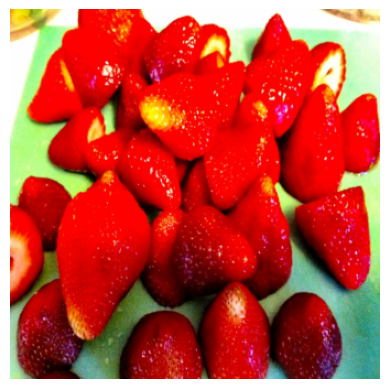

hypo: in this image we can see some strawberries the table surface.
refe: in this i can see there are red colored strawberries.
this pic. WER : 0.6666666666666666
this pic. BLEU: 0.6247616030574529
test number = 1 average, WER = 0.6666666865348816, BLEU = 0.6247615814208984





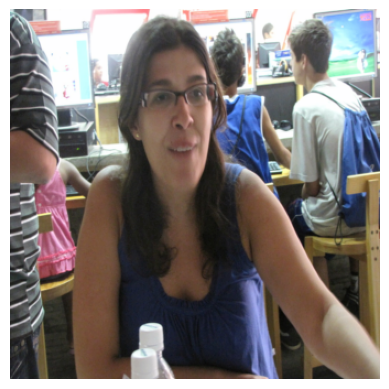

hypo: in this image i can see few people sitting sitting on the..
refe: there are few persons sitting on the chairs. here we can see monitors, keyboards, tables, and devices.
this pic. WER : 0.8636363636363636
this pic. BLEU: 0.31947446576212973
test number = 2 average, WER = 0.7651515007019043, BLEU = 0.4721180200576782





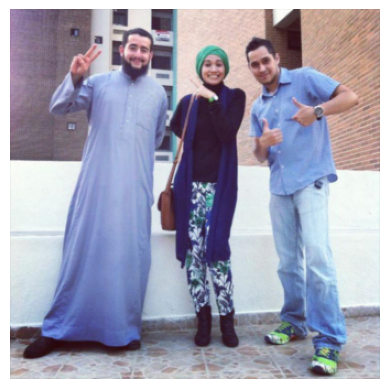

hypo: in this image we can see three persons standing on the the floor. buildings buildings.
refe: this image is taken outdoors. at the bottom of the there is a floor. in the background there are a few buildings with walls, windows and balconies. in the middle of the image two men and a woman are standing on the floor and they are with smiling faces.
this pic. WER : 0.8928571428571429
this pic. BLEU: 0.11606282923096954
test number = 3 average, WER = 0.8077200055122375, BLEU = 0.3534329831600189





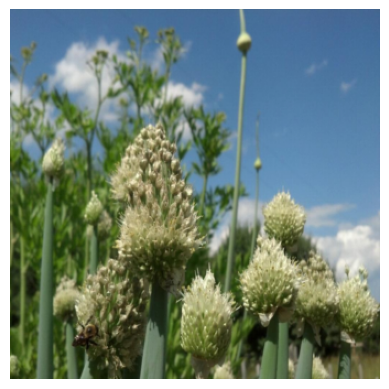

hypo: in this image we can see some,, flowers, plants, sky the the clouds.
refe: in this image in front there are plants. in the background of the image there is sky.
this pic. WER : 0.7894736842105263
this pic. BLEU: 0.45279990304290557
test number = 4 average, WER = 0.8031584620475769, BLEU = 0.37827470898628235





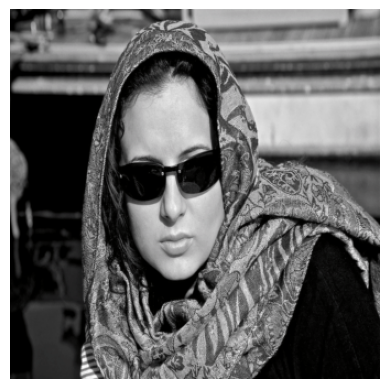

hypo: in this image we can see a woman wearing aggles.
refe: this is a black and white image. in this image we can see women wearing spectacles.
this pic. WER : 0.631578947368421
this pic. BLEU: 0.45330009958839473
test number = 5 average, WER = 0.7688425779342651, BLEU = 0.3932797908782959





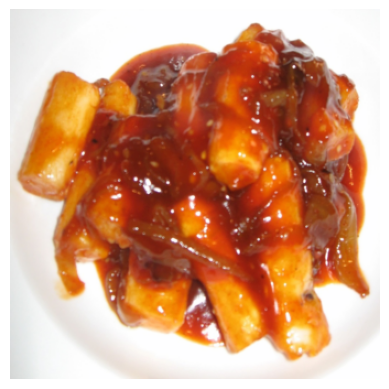

hypo: in this image we can see some food in the plate plate.
refe: as we can see in the image there is a white color plate. in plate there is a dish.
this pic. WER : 0.8095238095238095
this pic. BLEU: 0.4792515333256459
test number = 6 average, WER = 0.7756227850914001, BLEU = 0.40760841965675354





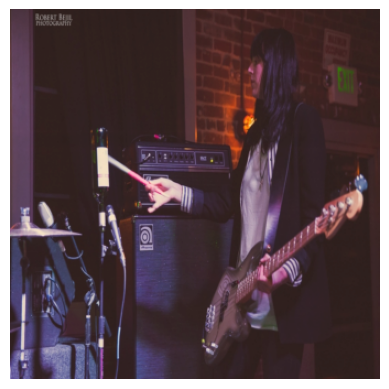

hypo: in this image i can see a woman is standing and a guitar in a
refe: this image is clicked in a musical concert where there is a woman standing and she is holding a guitar in her hand. she is wearing black color dress. there is a mic in front of her and there is a bottle. she is holding a stick. there are speakers back side and there are some musical instruments on the bottom left corner.
this pic. WER : 0.8676470588235294
this pic. BLEU: 0.01311929651057275
test number = 7 average, WER = 0.7887691259384155, BLEU = 0.35125282406806946





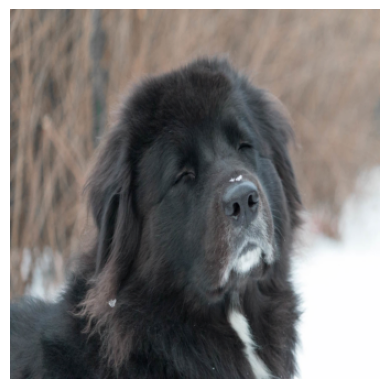

hypo: in this image we can see a dog.
refe: in this image, we can see a black color dog, there is a blurred background.
this pic. WER : 0.5
this pic. BLEU: 0.24153871270205204
test number = 8 average, WER = 0.7526729702949524, BLEU = 0.33753857016563416





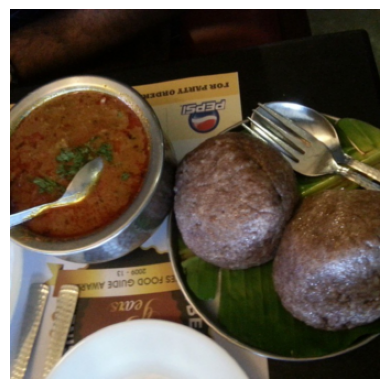

hypo: in this image we can see food items on a plate.
refe: in this picture there is a bowl and a plate in the center of the image, which contains food items in it.
this pic. WER : 0.7916666666666666
this pic. BLEU: 0.2416736801845192
test number = 9 average, WER = 0.7570055723190308, BLEU = 0.326886922121048





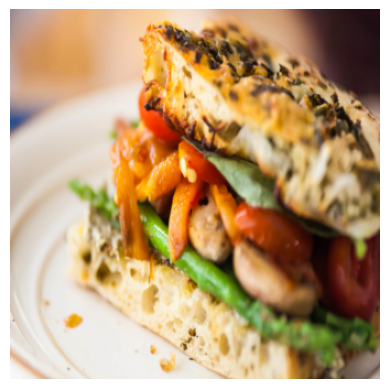

hypo: in this image we can see a food item the plate plate.
refe: in this picture i can observe some food places in the plate. the food is in brown, orange, green and red colors. it is looking like a burger. the background is completely blurred.
this pic. WER : 0.8205128205128205
this pic. BLEU: 0.07036031350037669
test number = 10 average, WER = 0.7633563280105591, BLEU = 0.30123424530029297





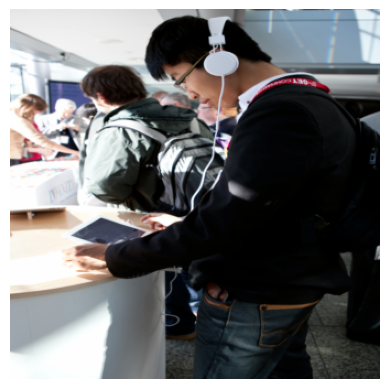

hypo: in this image we can see a group standing people some floor and
refe: in this image i can see a person standing wearing a black shirt, blue jeans and glasses. he is holding a electronic gadget in his hand. in the background i can see few people standing, and the ceiling of the building.
this pic. WER : 0.8085106382978723
this pic. BLEU: 0.07395890302600679
test number = 11 average, WER = 0.7674612402915955, BLEU = 0.2805728614330292





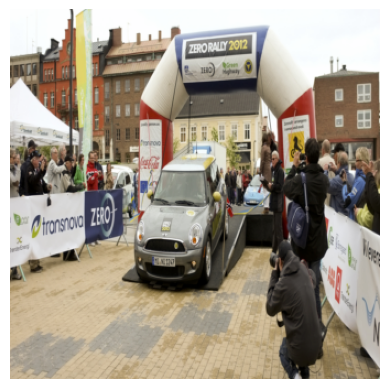

hypo: in this image we can see buildings, banners,,, banners,,,, sky and..
refe: in this image we can see cars, people, banners, hoardings, tent, pole, trees, boards, and buildings. in the background there is sky.
this pic. WER : 0.5294117647058824
this pic. BLEU: 0.345430104276125
test number = 12 average, WER = 0.7476237416267395, BLEU = 0.28597763180732727





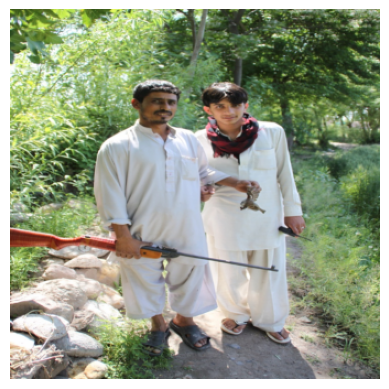

hypo: in this image we can see two standing standing and holding a gun. the we there are trees and and..
refe: in this image we can see two persons standing and holding the objects, there are some stones, grass, plants and trees, also we can see the sky.
this pic. WER : 0.625
this pic. BLEU: 0.5596540422693415
test number = 13 average, WER = 0.7381911873817444, BLEU = 0.307029664516449





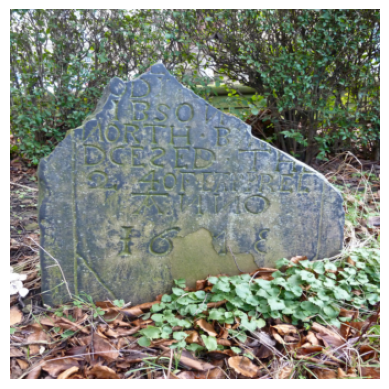

hypo: in this image we can see a stone, plants, and and..
refe: in front of the image there are some engravings on the headstone, around the headstone on the surface there are green leaves and dry leaves and sticks, behind the headstone there are trees and a wall.
this pic. WER : 0.8571428571428571
this pic. BLEU: 0.03473874000754297
test number = 14 average, WER = 0.7466877102851868, BLEU = 0.28758031129837036





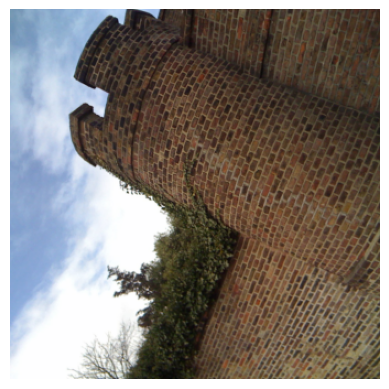

hypo: in this image we can see a,, trees, sky and sky clouds.
refe: in this picture i can see building and few trees and a cloudy sky.
this pic. WER : 0.6
this pic. BLEU: 0.5413609128079863
test number = 15 average, WER = 0.7369085550308228, BLEU = 0.3044990003108978





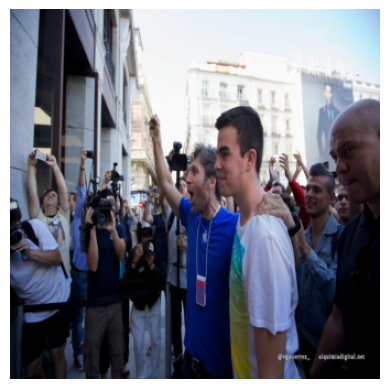

hypo: in this image we can see a group of people standing and holding the background we there some buildings.
refe: in this image there are many people in front of the building. some of them are holding camera. in the background there are buildings. there is a banner over here.
this pic. WER : 0.7352941176470589
this pic. BLEU: 0.4571905521725783
test number = 16 average, WER = 0.7368077039718628, BLEU = 0.31404221057891846





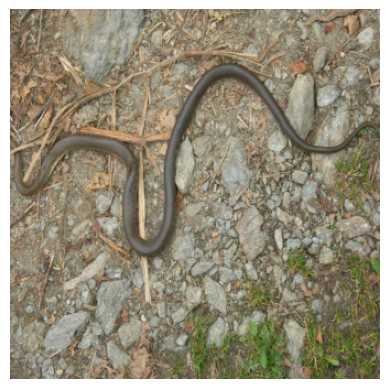

hypo: in this image we can see a snake on the and...
refe: in this image i can see a snake on the ground. it is in black color. i can see few wooden sticks, few stones and grass.
this pic. WER : 0.6
this pic. BLEU: 0.20100947378845824
test number = 17 average, WER = 0.7287602424621582, BLEU = 0.30739325284957886





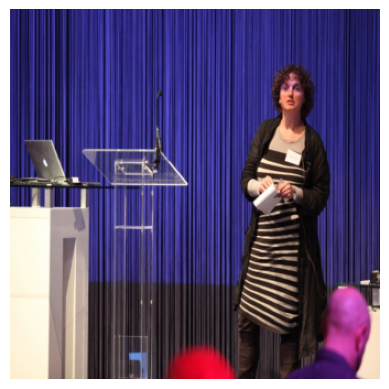

hypo: in this image we can see a woman standing and holding a paper. her there is see a..
refe: in this image we can see a person standing and holding a book and to the side we can see a podium with mic and there is a laptop and some other objects on the table. we can see a person standing in the bottom right.
this pic. WER : 0.6666666666666666
this pic. BLEU: 0.19437398934385508
test number = 18 average, WER = 0.7253105640411377, BLEU = 0.30111441016197205





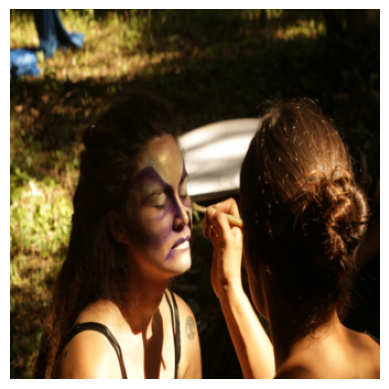

hypo: in this image we can see two women.
refe: in this picture i can see 2 women in front and the women right is holding a brush in her hand and i see the paint on the face of the woman on the left and in the background i see the grass and on the top left of this image i see the blue color things.
this pic. WER : 0.896551724137931
this pic. BLEU: 0.0019152827775531266
test number = 19 average, WER = 0.7343232035636902, BLEU = 0.28536707162857056





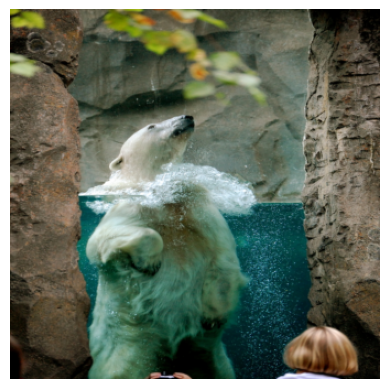

hypo: in this image we can see a bear bear and the water.
refe: in this image we can see an animal, water, rocks, and leaves. at the bottom of the image we can see a person who is truncated.
this pic. WER : 0.7096774193548387
this pic. BLEU: 0.2028533308805255
test number = 20 average, WER = 0.7330909967422485, BLEU = 0.28124135732650757





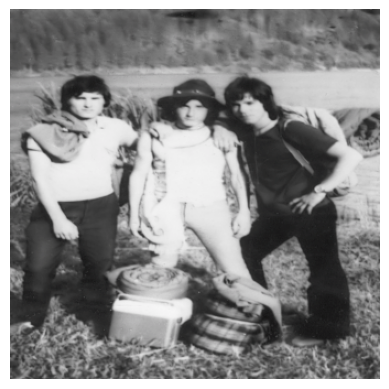

hypo: in this image we can see three standing standing on the ground,.
refe: in this image we can see three people, one of them is wearing a backpack, in front of them, we can see some bags, box, also we can see some plants, grass, and trees.
this pic. WER : 0.7857142857142857
this pic. BLEU: 0.16172690339062004
test number = 21 average, WER = 0.735596776008606, BLEU = 0.2755502164363861



test 21 average WER : 0.7355967920920637
test 21 average BLEU: 0.2755502224593148


In [222]:
test_num = 21
## top_k = None だと inference1 
top_k = None
#top_k = 5
temperature = 0.5

my_decode = False
#my_decode = True

# Subset samplerの生成
test_set, val_set, train_set = util.generate_subset_test_val_train(
    train_dataset, 0.1, 0.1 )

test_set = test_set[:test_num]

test_loader = torch.utils.data.DataLoader(
                    train_dataset,
                    #batch_size=config.batch_size,
                    batch_size=1,
                    num_workers=0,
                    sampler=test_set,
                    collate_fn=collate_func_lambda)

test_pr_coef = 1

fn = bleu_score.SmoothingFunction().method7

transforms_inv = v2.Compose([
    v2.Normalize((-0.48145466/0.26862954, -0.4578275/0.26130258, -0.40821073/0.27577711), (1/0.26862954,1/0.26130258,1/0.27577711)),
    v2.ToPILImage()
])

# test
with tqdm(test_loader) as pbar:
    pbar.set_description(f'[テスト]')
    if top_k is not None:
        print(f'top_k: {top_k}' )
        print(f'temperature: {temperature}' )

    # 評価モード
    model.eval()

    test_errors = deque()
    test_bleus = deque()
    n_iter = 0
    length_max = 84
    for k, (imgs, captions, caption_lengths) in enumerate( pbar ):
        #if k > 20:
        #    break
        # ミニバッチを設定
        imgs = imgs.to(device)
        captions = captions.to(device)
        #caption_lengths = torch.tensor( caption_lengths ).to(config.device)
        
        with torch.no_grad():
            #prop_logits = inference(imgs, tokenizer, length_max )
            #hypo_ids = torch.argmax( prop_logits, dim = 2 )
            if top_k is None:
                hypo_ids = inference(imgs, tokenizer, length_max )
            else:
                hypo_ids = inference2(imgs, tokenizer, length_max, top_k, temperature )
        
        n = 0
        hypo_sentence = []
        ref_sentence = []
        ref_imgs = []
        total_error = 0
        total_token_length = 0
        total_bleu = 0
        for (hypo_id, caption, img ) in zip( hypo_ids, captions, imgs ):
            if my_decode == True:
                hypo = model.my_decode( hypo_id.tolist(), tokenizer )
                hypo_tokens = tokenizer.tokenize( hypo )
                reference = model.my_decode( caption.tolist(), tokenizer )
                ref_tokens = tokenizer.tokenize( reference )
            else:
                hypo = tokenizer.decode( hypo_id.tolist(), skip_special_tokens = True )
                hypo_tokens = tokenizer.tokenize( hypo )
                reference = tokenizer.decode( caption.tolist(), skip_special_tokens = True )
                ref_tokens = tokenizer.tokenize( reference )
            
            # 認識誤りを計算
            (error, substitute, delete, insert, ref_length) = levenshtein.calculate_error(hypo_tokens,ref_tokens)
            
            # 誤り文字数を累積する
            total_error += error
            # 文字の総数を累積する
            total_token_length += ref_length

            bleu = bleu_score.sentence_bleu( [reference], hypo, smoothing_function=fn  )
        
            total_bleu += bleu

            inv_img = transforms_inv( img )
            plt.imshow( inv_img )
            plt.axis('off')
            plt.show()
            print( "hypo:", hypo )
            print( "refe:", reference )
            print( "this pic. WER :", error / ref_length )
            print( "this pic. BLEU:", bleu )
            test_errors.append(error / ref_length)
            test_bleus.append(bleu)
            n_iter += 1
            print(f'test number = {n_iter} average, WER = {torch.Tensor(test_errors).mean().item()}, BLEU = {torch.Tensor(test_bleus).mean().item()}')
            print( "\n\n" )
            
                
            #if len(test_errors) > config.moving_avg:
            if len(test_errors) > 100:
                test_errors.popleft()
                test_bleus.popleft()
            pbar.set_postfix({
                #'loss': torch.Tensor(test_losses).mean().item(),
                'WER': torch.Tensor(test_errors).mean().item(),
                'BLEU': torch.Tensor(test_bleus).mean().item()
            })                

# 表示
test_error = np.mean( test_errors )
test_bleu = np.mean( test_bleus )
if top_k is not None:
    print(f'top_k: {top_k}' )
    print(f'temperature: {temperature}' )
print(f'test {n_iter} average WER : {test_error}')
print(f'test {n_iter} average BLEU: {test_bleu}')

In [ ]:
reference="A selection of scissors, including pinking shears, under a glass shelf."
ref = reference.split( " " )
hypo="A bunch of scissors that are on a table.OTHER.R."
hyp = hypo.split( " " )

(error, substitute, delete, insert, ref_length) = levenshtein.calculate_error(hyp,ref)

print( error, substitute, delete, insert, ref_length )
print( error / ref_length * 100 )